<a href="https://colab.research.google.com/github/mvinegret/ecommerce_analytics_SQL_Python_Tableau/blob/main/E-commerce%20Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Import

In [159]:
from google.colab import auth
from google.cloud import bigquery
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import pearsonr, mannwhitneyu, shapiro, kruskal
from statsmodels.stats.proportion import proportions_ztest

In [160]:
auth.authenticate_user()
client = bigquery.Client(project='data-analytics-mate')

In [161]:
query = '''
SELECT
    CASE WHEN o.ga_session_id IS NOT NULL THEN s.date ELSE NULL END AS order_date,
    sp.continent,
    sp.country,
    sp.device,
    sp.browser,
    sp.mobile_model_name,
    sp.operating_system,
    sp.language,
    sp.medium AS source_info,
    sp.channel,
    acc.id AS user_id,
    acc.is_verified,
    acc.is_unsubscribed,
    p.category,
    p.name,
    p.price,
    p.short_description
FROM `DA.session` AS s
LEFT JOIN `DA.session_params` AS sp
  ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `DA.order` AS o
  ON s.ga_session_id = o.ga_session_id
LEFT JOIN `DA.product` AS p
  ON o.item_id = p.item_id
LEFT JOIN `DA.account_session` AS acs
  ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `DA.account` AS acc
  ON acs.account_id = acc.id
'''

query_job = client.query(query)
output = query_job.result()

In [162]:
df = output.to_dataframe()
df.head()

,order_date,continent,country,device,browser,mobile_model_name,operating_system,language,source_info,channel,user_id,is_verified,is_unsubscribed,category,name,price,short_description
0,2020-11-01,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [163]:
# Identifying the date range
date_range = df['order_date'].agg(['min', 'max'])
print(date_range)

min    2020-11-01
max    2021-01-27
Name: order_date, dtype: object


In [164]:
# Reviewing null values inside the dataset
print(df.isna().sum())

order_date           316007
continent                 0
country                   0
device                    0
browser                   0
mobile_model_name         0
operating_system          0
language             114266
source_info               0
channel                   0
user_id              321600
is_verified          321600
is_unsubscribed      321600
category             316007
name                 316007
price                316007
short_description    316007
dtype: int64


In [165]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   order_date         33538 non-null   dbdate 
 1   continent          349545 non-null  object 
 2   country            349545 non-null  object 
 3   device             349545 non-null  object 
 4   browser            349545 non-null  object 
 5   mobile_model_name  349545 non-null  object 
 6   operating_system   349545 non-null  object 
 7   language           235279 non-null  object 
 8   source_info        349545 non-null  object 
 9   channel            349545 non-null  object 
 10  user_id            27945 non-null   Int64  
 11  is_verified        27945 non-null   Int64  
 12  is_unsubscribed    27945 non-null   Int64  
 13  category           33538 non-null   object 
 14  name               33538 non-null   object 
 15  price              33538 non-null   float64
 16  sh

As a lot of our columns are `object` type, we can switch them to `category` for memory savings.

##Memory optimization

In [166]:
# Checking unique value counts for object columns
object_cols = df.select_dtypes(include='object').columns

for col in object_cols:
    n_unique = df[col].nunique()
    print(f'{col}: {n_unique} unique values')

continent: 6 unique values
country: 108 unique values
device: 3 unique values
browser: 6 unique values
mobile_model_name: 10 unique values
operating_system: 6 unique values
language: 9 unique values
source_info: 6 unique values
channel: 5 unique values
category: 14 unique values
name: 550 unique values
short_description: 1476 unique values


In [167]:
# Columns that have low amounts of unique values to be converted into category dtype
categorical_cols = ['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'source_info', 'channel', 'category']

# Convert to category dtype
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [168]:
print('Memory usage comparison:')
print(df.info(memory_usage='deep'))

Memory usage comparison:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   order_date         33538 non-null   dbdate  
 1   continent          349545 non-null  category
 2   country            349545 non-null  category
 3   device             349545 non-null  category
 4   browser            349545 non-null  category
 5   mobile_model_name  349545 non-null  category
 6   operating_system   349545 non-null  category
 7   language           235279 non-null  category
 8   source_info        349545 non-null  category
 9   channel            349545 non-null  category
 10  user_id            27945 non-null   Int64   
 11  is_verified        27945 non-null   Int64   
 12  is_unsubscribed    27945 non-null   Int64   
 13  category           33538 non-null   category
 14  name               33538 non-null   object  
 15  price    

This saved us 170.6mb of memory.

#Data Overview

**Total # of columns**: 17  
**Total # of rows**: 349,545  
**Column breakdown by type**:
- `category` type columns - 10
- `int64` type columns - 3
- `object` type columns - 2
- `dbdate` type columns - 1
- `float64` type columns - 1  

**Data range**: 01-11-2020 - 27-01-2021   
**Column description**:
- order_date (dtype = `dbdate`) - The **date of the order** (if it was made). Contains 316,007 null values, which indicates that ≈90.4% of sessions did not result in a purchase;
- continent (dtype = `category`) - **Continent name**, does not contain null values;
- country (dtype = `category`) - **Country name**, does not contain null values;
- device (dtype = `category`) - **Device type**, does not contain null values;
- browser (dtype = `category`) - **Web browser**, does not contain null values;
- mobile_model_name (dtype = `category`) - **Mobile device model**, does not contain null values;
- operating_system (dtype = `category`) - **Operating system**, does not contain null values;
- language (dtype = `category`) - **Browser language**, contains 114,266 null values. This means that for these sessions (≈ 32.7%) we did not collect language data from the users web browser;
- source_info (dtype = `category`) - **Traffic source**, does not contain null values;
- channel (dtype = `category`) - **Traffic channel**, does not contain null values;
- user_id (dtype = `int64`) - **User ID**, contains 321,600 null values. User ID is only present for registered users, which indicates that 92% of users are not registered on the website. This also applies for *is_verified* and *is_unsubscribed* fields;
- is_verified (dtype = `int64`) - **User email verification (1 or 0)**, contains 321,600 null values.
- is_unsubscribed (dtype = `int64`) - **User email unsubscribe (1 or 0)**, contains 321,600 null values.
- category (dtype = `category`) - **Product category**, contains 316,007 null values, which corresponds with the amount of orders.
- name (dtype = `object`) - **Product name**, contains 316,007 null values, which corresponds with the amount of orders.
- price (dtype = `float64`) - **Product price (in USD)**, contains 316,007 null values, which corresponds with the amount of orders.
- short_description (dtype = `object`) - **Product description**, contains 316,007 null values, which corresponds with the amount of orders.

In [169]:
print(f'Total # of orders: {df['order_date'].count()}')
print(f'Total order value: ${df['price'].sum():,.2f}')
print(f'% of sessions with orders: {df['order_date'].count() / df['channel'].count() * 100 :.2f}%')
print('-' * 50)
print(f'Total # of countries: {df['country'].nunique()}')
print(f'Total # of product categories: {df['category'].nunique()}')

Total # of orders: 33538
Total order value: $31,971,731.10
% of sessions with orders: 9.59%
--------------------------------------------------
Total # of countries: 108
Total # of product categories: 14


##Region analytics

### Sales Breakdown

In [170]:
print(f'''Top continents by total sales:\n
{df.groupby('continent', observed=True)['price'].sum().sort_values(ascending=False)}''')
print('-' * 50)

print(f'''Top 10 countries by total sales:\n
{df.groupby('country', observed=True)['price'].sum().sort_values(ascending=False).head(10)}''')
print('-' * 50)

print(f'''Top continents by # of orders:\n
{df.groupby('continent', observed=True)['order_date'].count().sort_values(ascending=False)}''')
print('-' * 50)

print(f'''Top 10 countries by # of orders:\n
{df.groupby('country', observed=True)['order_date'].count().sort_values(ascending=False).head(10)}''')


Top continents by total sales:

continent
Americas     17665280.0
Asia          7601298.3
Europe        5934624.2
Oceania        365230.2
Africa         331231.0
(not set)       74067.4
Name: price, dtype: float64
--------------------------------------------------
Top 10 countries by total sales:

country
United States     13943553.9
India              2809762.0
Canada             2437921.0
United Kingdom      938317.9
France              710692.8
Spain               631546.7
Germany             599221.4
China               588329.6
Taiwan              552710.3
Singapore           456447.2
Name: price, dtype: float64
--------------------------------------------------
Top continents by # of orders:

continent
Americas     18553
Asia          7950
Europe        6261
Oceania        364
Africa         339
(not set)       71
Name: order_date, dtype: int64
--------------------------------------------------
Top 10 countries by # of orders:

country
United States     14673
India              3

### Registration breakdown by region

In [171]:
print(f'''Top continents by registered users:\n
{df.groupby('continent', observed=True)['user_id'].count().sort_values(ascending=False)}''')
print('-' * 50)

print(f'''Top 10 countries by registered users:\n
{df.groupby('country', observed=True)['user_id'].count().sort_values(ascending=False).head(10)}''')

Top continents by registered users:

continent
Americas     15520
Asia          6664
Europe        5170
Oceania        272
Africa         266
(not set)       53
Name: user_id, dtype: Int64
--------------------------------------------------
Top 10 countries by registered users:

country
United States     12384
India              2687
Canada             2067
United Kingdom      859
France              553
Spain               536
Taiwan              500
China               490
Germany             490
Italy               386
Name: user_id, dtype: Int64


### Region analytics Conclusions

#### Geographic distribution

- The **Americas** dominate both sales (17.6M USD, 55% of total) and order volume (18,553 orders), driven primarily by the United States which alone accounts for 13.9M USD in revenue and 14,673 orders.
- **Asia** is a strong second market with 7.6M USD in sales and 7,950 orders, led by India (2.8M USD) and China (588K USD).
- **Europe** contributes 5.9M USD across a variety of small contributions from different countries (UK, France, Spain, Germany all in a similar range of 600K-940K USD).

#### Registration vs Orders comparison by region

Across all regions we can see many guest checkouts, especially for our top-3 regions observed:
- **Americas**: 15,520 registered users vs 18,553 orders
- **Asia**: 6,664 registered users vs 7,950 orders
- **Europe**: 5,170 registered users vs 6,261 orders

Overall ≈20% of total orders are placed by unregistered users.

Another insight here is that while Italy is in our top-10 countries by registered users, it doesn't reach top-10 by orders or revenue, which indicates low registrations to purchases conversion for that region.

## Product category analytics

In [172]:
print(f'''Top 10 categories by total sales:\n
{df.groupby('category', observed=True)['price'].sum().sort_values(ascending=False).head(10)}''')
print('-' * 50)

print(f'''Top 10 categories by # of orders:\n
{df.groupby('category', observed=True)['category'].count().sort_values(ascending=False).head(10)}''')

Top 10 categories by total sales:

category
Sofas & armchairs                   8388254.5
Chairs                              6147748.8
Beds                                4919725.0
Bookcases & shelving units          3640818.1
Cabinets & cupboards                2336499.5
Outdoor furniture                   2142222.2
Tables & desks                      1790307.5
Chests of drawers & drawer units     906562.5
Bar furniture                        735503.0
Children's furniture                 467697.0
Name: price, dtype: float64
--------------------------------------------------
Top 10 categories by # of orders:

category
Bookcases & shelving units          7630
Chairs                              5952
Sofas & armchairs                   4301
Tables & desks                      2941
Beds                                2926
Cabinets & cupboards                2318
Outdoor furniture                   2229
Children's furniture                1702
Chests of drawers & drawer units    1452
Bar 

In [173]:
print(f'''Top 10 categories (% of total sales):\n
{(df.groupby('category', observed=True)['price'].sum().sort_values(ascending=False).head(10) / df['price'].sum() * 100).map('{:.2f}%'.format)}''')
print('-' * 50)

print(f'''Top 10 categories (% of total orders):\n
{(df.groupby('category', observed=True)['category'].count().sort_values(ascending=False).head(10) / df['order_date'].count() * 100).map('{:.2f}%'.format)}''')

Top 10 categories (% of total sales):

category
Sofas & armchairs                   26.24%
Chairs                              19.23%
Beds                                15.39%
Bookcases & shelving units          11.39%
Cabinets & cupboards                 7.31%
Outdoor furniture                    6.70%
Tables & desks                       5.60%
Chests of drawers & drawer units     2.84%
Bar furniture                        2.30%
Children's furniture                 1.46%
Name: price, dtype: object
--------------------------------------------------
Top 10 categories (% of total orders):

category
Bookcases & shelving units          22.75%
Chairs                              17.75%
Sofas & armchairs                   12.82%
Tables & desks                       8.77%
Beds                                 8.72%
Cabinets & cupboards                 6.91%
Outdoor furniture                    6.65%
Children's furniture                 5.07%
Chests of drawers & drawer units     4.33%
Bar furn

### Category breakdown for №1 country by sales (United States)

In [174]:
print(f'''Top 10 categories by total sales in United States:\n
{df[df['country'] == 'United States'].groupby('category', observed=True)['price'].sum().sort_values(ascending=False).head(10)}''')
print('-' * 50)

print(f'''Top 10 categories by # of orders in United States:\n
{df[df['country'] == 'United States'].groupby('category', observed=True)['category'].count().sort_values(ascending=False).head(10)}''')

Top 10 categories by total sales in United States:

category
Sofas & armchairs                   3707144.5
Chairs                              2619773.8
Beds                                2213058.0
Bookcases & shelving units          1567606.9
Cabinets & cupboards                 994545.5
Outdoor furniture                    929245.2
Tables & desks                       777865.0
Chests of drawers & drawer units     382388.0
Bar furniture                        330805.0
Children's furniture                 207575.0
Name: price, dtype: float64
--------------------------------------------------
Top 10 categories by # of orders in United States:

category
Bookcases & shelving units          3374
Chairs                              2576
Sofas & armchairs                   1903
Beds                                1298
Tables & desks                      1248
Cabinets & cupboards                 995
Outdoor furniture                    984
Children's furniture                 752
Chests of d

### Product category analytics conclusions

#### Category insights

- **Sofas & armchairs** is the top revenue category (26.24%, $8.4M) but only 3rd by order volume (12.82%), meaning it's a high-value, less frequent purchase
- **Bookcases & shelving units** is the opposite: #1 by order count (22.75%) but only #4 by revenue (11.39%), high volume, lower price point
- **Chairs** consistently rank #2 in both metrics, making them the most balanced category

For our top-3 categories, this indicates 2 distinct customer behaviours: high-ticket occasional purchases (**Sofas & armchairs**) vs. affordable frequent purchases (**Bookcases & shelving units**).

#### US-specific insights

There is no noticeable difference between US and global trends, as the US mirrors global trends almost exactly in category rankings, which makes sense given it represents ≈44% of all sales. **Sofas & armchairs** lead in revenue ($3.7M), **Bookcases** lead in orders (3,374) - same pattern as global. **Children's furniture** ranks last in revenue and 3rd last orders in the US.

## Device analytics

In [175]:
print(f'''Top devices by total sales:\n
{df.groupby('device', observed=True)['price'].sum().sort_values(ascending=False)}''')

print('-' * 50)

print(f'''Top devices by # of orders:\n
{df.groupby('device', observed=True)['order_date'].count().sort_values(ascending=False).head(10)}''')

print('-' * 50)

print(f'''Top mobile model names by total sales:\n
{df.groupby('mobile_model_name', observed=True)['price'].sum().sort_values(ascending=False)}''')

print('-' * 50)

print(f'''Top devices by # of orders:\n
{df.groupby('mobile_model_name', observed=True)['order_date'].count().sort_values(ascending=False).head(10)}''')

Top devices by total sales:

device
desktop    18864039.0
mobile     12384225.8
tablet       723466.3
Name: price, dtype: float64
--------------------------------------------------
Top devices by # of orders:

device
desktop    19702
mobile     13113
tablet       723
Name: order_date, dtype: int64
--------------------------------------------------
Top mobile model names by total sales:

mobile_model_name
Chrome        8899523.9
<Other>       6535330.8
Safari        6491062.1
iPhone        6420776.3
ChromeBook    1830458.7
Edge           697222.3
iPad           448854.2
Firefox        421066.9
Pixel 4 XL     118287.7
Pixel 3        109148.2
Name: price, dtype: float64
--------------------------------------------------
Top devices by # of orders:

mobile_model_name
Chrome        9359
Safari        6833
iPhone        6819
<Other>       6801
ChromeBook    1877
Edge           741
iPad           456
Firefox        430
Pixel 4 XL     117
Pixel 3        105
Name: order_date, dtype: int64


In [176]:
print(f'''Top devices (% of total sales):\n
{(df.groupby('device', observed=True)['price'].sum().sort_values(ascending=False) / df['price'].sum() * 100).map('{:.2f}%'.format)}''')

print('-' * 50)

print(f'''Top devices (% of total orders):\n
{(df.groupby('device', observed=True)['order_date'].count().sort_values(ascending=False).head(10) / df['order_date'].count() * 100).map('{:.2f}%'.format)}''')

print('-' * 50)

print(f'''Top mobile model names (% of total sales):\n
{(df.groupby('mobile_model_name', observed=True)['price'].sum().sort_values(ascending=False) / df['price'].sum() * 100).map('{:.2f}%'.format)}''')

print('-' * 50)

print(f'''Top devices (% of total orders):\n
{(df.groupby('mobile_model_name', observed=True)['order_date'].count().sort_values(ascending=False).head(10) / df['order_date'].count() * 100).map('{:.2f}%'.format)}''')

Top devices (% of total sales):

device
desktop    59.00%
mobile     38.73%
tablet      2.26%
Name: price, dtype: object
--------------------------------------------------
Top devices (% of total orders):

device
desktop    58.75%
mobile     39.10%
tablet      2.16%
Name: order_date, dtype: object
--------------------------------------------------
Top mobile model names (% of total sales):

mobile_model_name
Chrome        27.84%
<Other>       20.44%
Safari        20.30%
iPhone        20.08%
ChromeBook     5.73%
Edge           2.18%
iPad           1.40%
Firefox        1.32%
Pixel 4 XL     0.37%
Pixel 3        0.34%
Name: price, dtype: object
--------------------------------------------------
Top devices (% of total orders):

mobile_model_name
Chrome        27.91%
Safari        20.37%
iPhone        20.33%
<Other>       20.28%
ChromeBook     5.60%
Edge           2.21%
iPad           1.36%
Firefox        1.28%
Pixel 4 XL     0.35%
Pixel 3        0.31%
Name: order_date, dtype: object


### Device analytics conclusions

Desktop remains the primary purchase channel (≈59%), though mobile represents a significant ≈39% share with comparable average order values across devices. The mobile_model_name field captures a mix of browsers and device models, indicating a data collection inconsistency that limits deeper device-level analysis.

## Traffic source analytics

In [177]:
print(f'''Sales by traffic source:\n
{df.groupby('source_info', observed=True)['price'].sum().sort_values(ascending=False)}''')

print('-' * 50)

print(f'''Orders by traffic source:\n
{df.groupby('source_info', observed=True)['order_date'].count().sort_values(ascending=False).head(10)}''')

print(f'''Sales by traffic source (% of total):\n
{(df.groupby('source_info', observed=True)['price'].sum().sort_values(ascending=False) / df['price'].sum() * 100).map('{:.2f}%'.format)}''')

print('-' * 50)

print(f'''Orders by traffic source (% of total):\n
{(df.groupby('source_info', observed=True)['order_date'].count().sort_values(ascending=False).head(10) / df['order_date'].count() * 100).map('{:.2f}%'.format)}''')

Sales by traffic source:

source_info
organic           10935239.9
(none)             7494923.4
referral           5641855.2
<Other>            4491351.1
(data deleted)     2041921.0
cpc                1366440.5
Name: price, dtype: float64
--------------------------------------------------
Orders by traffic source:

source_info
organic           11430
(none)             7800
referral           6001
<Other>            4803
(data deleted)     2097
cpc                1407
Name: order_date, dtype: int64
Sales by traffic source (% of total):

source_info
organic           34.20%
(none)            23.44%
referral          17.65%
<Other>           14.05%
(data deleted)     6.39%
cpc                4.27%
Name: price, dtype: object
--------------------------------------------------
Orders by traffic source (% of total):

source_info
organic           34.08%
(none)            23.26%
referral          17.89%
<Other>           14.32%
(data deleted)     6.25%
cpc                4.20%
Name: order_da

### Traffic source analytics conclusions

Organic search is the dominant acquisition channel (≈34%), followed by direct traffic (≈23%) and referral (≈18%). Paid CPC accounts for only ≈4% of revenue, suggesting the business relies heavily on non-paid channels. Approximately 6.4% of revenue cannot be attributed due to deleted data, likely reflecting privacy compliance (e.g. GDPR). Average order value remains consistent across all traffic sources.

## Registration analytics

In [178]:
print(f'Total # of registered users: {df['user_id'].count()}')

print('-' * 50)

print(f'% of sessions with registered users: {(df['user_id'].count() / df['channel'].count() * 100):.2f}%')
print(f'% of registered users with verified email: {(df[df['is_verified'] == 1]['user_id'].count() / df['user_id'].count() * 100):.2f}%')
print(f'% of registered users that unsubscribed: {(df[df['is_unsubscribed'] == 1]['user_id'].count() / df['user_id'].count() * 100):.2f}%')

Total # of registered users: 27945
--------------------------------------------------
% of sessions with registered users: 7.99%
% of registered users with verified email: 71.70%
% of registered users that unsubscribed: 16.94%


### Breakdown by region

In [179]:
print(f'''Top continents by registered users:\n
{df.groupby('continent', observed=True)['user_id'].count().sort_values(ascending=False)}''')
print('-' * 50)

print(f'''Top 10 countries by registered users:\n
{df.groupby('country', observed=True)['user_id'].count().sort_values(ascending=False).head(10)}''')

Top continents by registered users:

continent
Americas     15520
Asia          6664
Europe        5170
Oceania        272
Africa         266
(not set)       53
Name: user_id, dtype: Int64
--------------------------------------------------
Top 10 countries by registered users:

country
United States     12384
India              2687
Canada             2067
United Kingdom      859
France              553
Spain               536
Taiwan              500
China               490
Germany             490
Italy               386
Name: user_id, dtype: Int64


### Breakdown of sales by registration status

In [180]:
subscription_pivot = df.pivot_table(
    index='is_unsubscribed',
    values='price',
    aggfunc=['sum','mean','count'],
    dropna=False
)

subscription_pivot.index = ['Subscribed', 'Unsubscribed', 'Unknown']
subscription_pivot.columns = ['Total sales amount', 'Average sales', '# of orders']

print('Pivot table - User behavior by subscription status')
subscription_pivot

Pivot table - User behavior by subscription status


,Total sales amount,Average sales,# of orders
Subscribed,2150796.9,921.506812,2334
Unsubscribed,431721.6,965.820134,447
Unknown,29389212.6,955.529232,30757


### Registration analytics conclusions

####Overall Registration Metrics

- Only 7.99% of sessions come from registered users, the vast majority of traffic is anonymous, which is typical for ecommerce but suggests significant growth potential in user registration
- 71.70% of registered users have verified emails, which is a healthy majority, good for marketing reachability
- 16.94% unsubscribe rate is worth monitoring - not alarming but means ≈1 in 6 registered users has opted out of communications

####Geographic Distribution

- Americas account for 55.5% of registered users (15,520), mirroring the sales distribution
- The US alone has 12,384 registered users out of 27,945 total (≈44%) - heavy concentration in one market

####Subscription Behavior (Pivot Table)

- The 'Unknown' category (30,757 orders, 29.4M USD) dominates overwhelmingly: these are guest/unregistered users, confirming the 92% anonymous session rate
- Subscribed vs Unsubscribed average order values are nearly identical (921 vs 965 USD), this indicates that subscription status doesn't meaningfully affect how much people spend
- Unsubscribed users still purchase (447 orders), opting out of emails doesn't mean they stop buying

## Data overview conclusions

This ecommerce dataset of 349,545 sessions (Nov 2020 - Jan 2021) reveals a business driven primarily by anonymous traffic (92%), organic search (34%), and desktop devices (59%), with the **Americas** accounting for ≈44% of all revenue (13.9M USD of 32M USD total).

The top revenue categories are **Sofas & armchairs** and **Chairs**, though **Bookcases & shelving units** lead in order volume, highlighting a clear split between high-ticket and high-frequency purchase behavior.

With only 7.99% of sessions from registered users and a consistent ≈20% guest checkout rate, there is meaningful opportunity to improve user registration and email capture. Subscription status has negligible impact on average order value (921 USD vs 965 USD), suggesting that purchase intent is driven by factors other than email engagement.

Key data quality considerations include mixed browser/device values in the mobile_model_name field and ≈6.4% of revenue with deleted attribution data, likely reflecting GDPR compliance.

# Sales over time analytics

## Sales over time

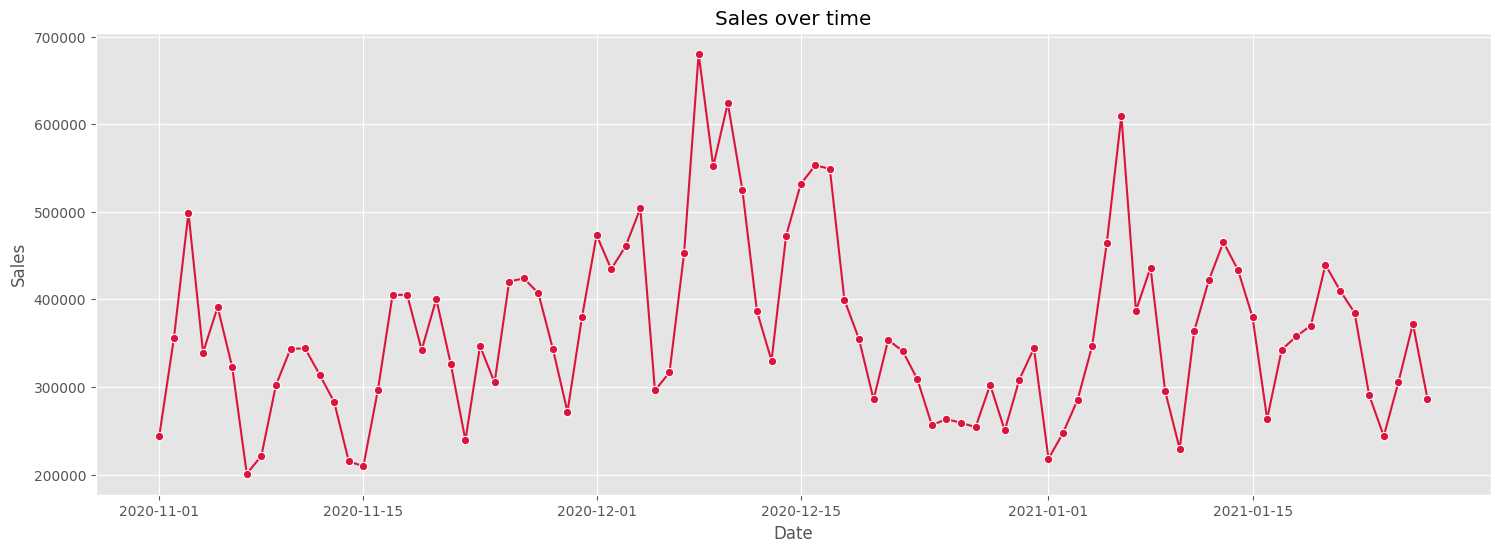

In [181]:
sales_over_time = df.groupby('order_date')['price'].sum()

plt.style.use('ggplot')
plt.figure(figsize=(18, 6))
sns.lineplot(x = sales_over_time.index, y = sales_over_time.values, marker='o', color = 'crimson', errorbar = None)
plt.title('Sales over time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

### Insights

- There's a clear Black Friday/Cyber Monday spike in early December (≈Dec 8-10 range hitting ≈680K), which is the single highest peak in the entire period
- Sales are generally higher in December than November, with January settling back to a lower but stable baseline (≈300-400K range)
- The high day-to-day volatility throughout suggests either small absolute order volumes (a few big orders can swing daily totals significantly) or spiky demand patterns

## Sales over time by continent

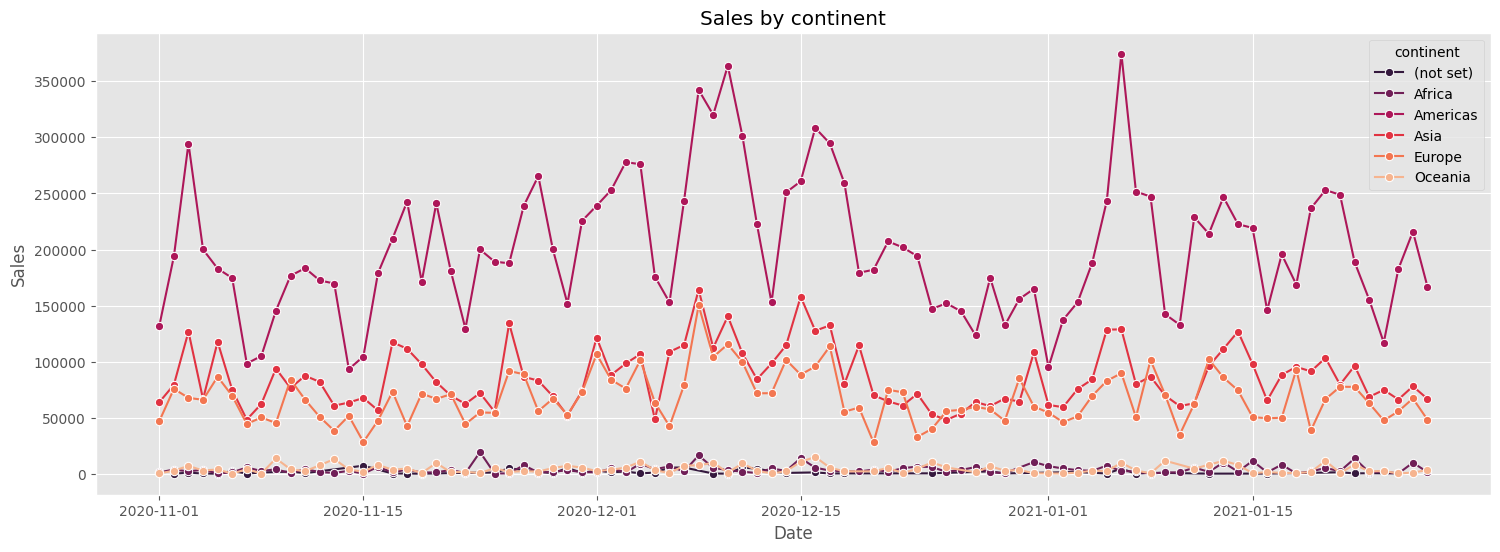

In [182]:
sales_by_continent = df.groupby(['order_date', 'continent'], observed=True)['price'].sum().reset_index()

plt.style.use('ggplot')
plt.figure(figsize=(18, 6))
sns.lineplot(data = sales_by_continent, x = 'order_date', y = 'price', hue = 'continent', marker='o', palette = 'rocket', errorbar = None)
plt.title('Sales by continent')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

### Insights

- The Americas spike in early December is the primary driver of the overall sales peak, other continents show much more muted holiday spikes
- Asia and Europe track each other fairly closely throughout, both significantly below Americas
- Africa and Oceania are essentially flat lines near zero, confirming their marginal contribution
- The Americas line becomes noticeably more volatile from December onwards, suggesting holiday shopping behavior concentrated there

## Sales over time by traffic source

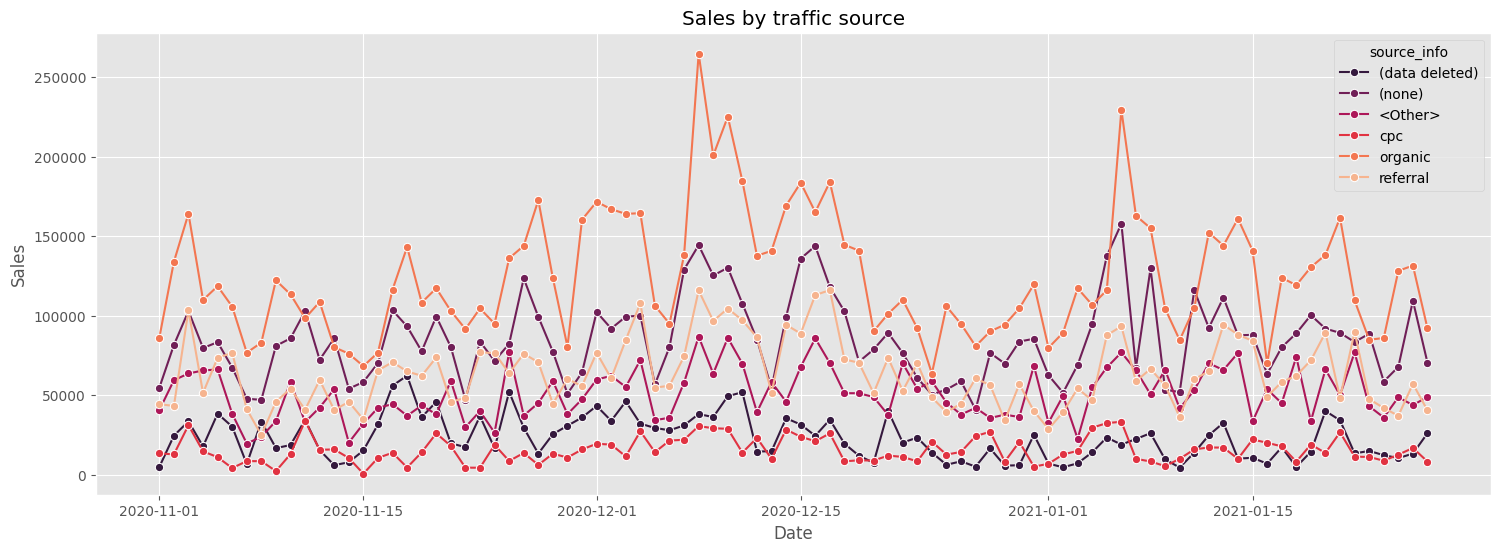

In [183]:
sales_by_source = df.groupby(['order_date', 'source_info'], observed=True)['price'].sum().reset_index()

plt.style.use('ggplot')
plt.figure(figsize=(18, 6))
sns.lineplot(data = sales_by_source, x = 'order_date', y = 'price', hue = 'source_info', marker='o', palette = 'rocket', errorbar = None)
plt.title('Sales by traffic source')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

### Insights

- Organic traffic drives the biggest December spike, confirming customers were actively searching for the products rather than being pushed by ads
- Referral and (none)/direct traffic move fairly consistently together throughout
- CPC remains consistently low and flat the entire period, reinforcing the earlier finding that paid ads play a minimal role
- No single source dramatically changes behavior in January, suggesting the post-holiday slowdown affects all channels equally

## Sales over time by device

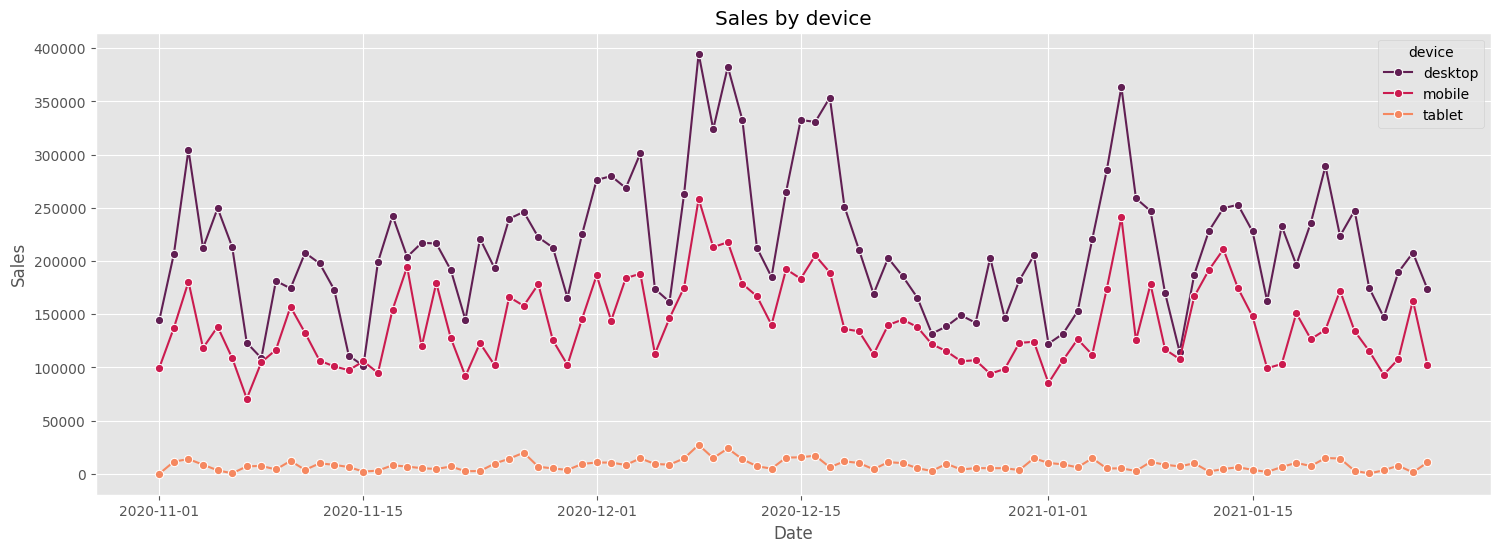

In [184]:
sales_by_device = df.groupby(['order_date', 'device'], observed=True)['price'].sum().reset_index()

plt.style.use('ggplot')
plt.figure(figsize=(18, 6))
sns.lineplot(data = sales_by_device, x = 'order_date', y = 'price', hue = 'device', marker='o', palette = 'rocket', errorbar = None)
plt.title('Sales by device')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

### Insights

- Desktop and mobile move almost in perfect parallel throughout the entire period, with desktop consistently 1.5-2x higher
- Both show the same December peak simultaneously, meaning the holiday spike wasn't device-specific
- The gap between desktop and mobile actually widens slightly during the December peak, suggesting desktop users drove slightly more of the holiday spending
- Tablet remains essentially flat and negligible throughout

# Pivot Tables

## Traffic by known devices

In [185]:
unknown_labels = ['(data deleted)', '(none)', '']
df_cleaned = df[~df['source_info'].isin(unknown_labels)].copy()
df_cleaned['source_info'] = df_cleaned['source_info'].cat.remove_unused_categories()

traffic_by_device_pivot = df_cleaned.pivot_table(index='source_info', columns='device', values='price', aggfunc='count', observed=True)

print('Traffic by devices pivot table')
traffic_by_device_pivot

Traffic by devices pivot table


device,desktop,mobile,tablet
source_info,,,
<Other>,2799,1883,121
cpc,808,558,41
organic,6745,4447,238
referral,3490,2392,119


### Insights

- The desktop/mobile/tablet ratio (≈60/38/2%) holds consistently across all traffic sources: organic, referral, CPC and Other all show the same pattern, meaning device preference is independent of how users find the site
- Organic dominates every device type as expected, with desktop organic (6,745) being the single largest segment

## Sales by category & country

In [186]:
top_5_countries = df['country'].value_counts().head(5).index
top_10_categories = df['category'].value_counts().head(10).index

categories_by_countries_pivot = df[df['country'].isin(top_5_countries) & df['category'].isin(top_10_categories)].pivot_table(index = 'category', columns = 'country', values = 'price', aggfunc = 'sum', observed = True)

print('Sales by top 10 categories from top 5 countries pivot table')
categories_by_countries_pivot

Sales by top 10 categories from top 5 countries pivot table


country,Canada,France,India,United Kingdom,United States
category,,,,,
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


### Insights

- Sofas & armchairs is the #1 revenue category in every single top-5 country without exception
- The US dwarfs all other markets in every category - US Sofas alone (3.7M USD) exceeds the entire revenue of Canada or India combined
- India and Canada are surprisingly close across most categories despite India having a much larger population, suggesting Canada has higher average spend
- France is notably weak in volume but has the highest average order value (see next pivot table), which explains its presence in the top 5

## Average & median price by country

In [187]:
avg_med_price_by_country = df[df['country'].isin(top_5_countries)].pivot_table(index = 'country', values = 'price', aggfunc = ['mean', 'median'], observed = True)

# Сортування таблиці
avg_med_price_by_country = avg_med_price_by_country.sort_values(('mean', 'price'), ascending=False)

print('Sales by top 5 countries pivot table')
avg_med_price_by_country


Sales by top 5 countries pivot table


,mean,median
,price,price
country,,
France,1048.219469,497.5
Canada,952.312891,445.0
United States,950.286506,440.0
India,927.620337,420.0
United Kingdom,911.873567,445.0


### Insights

- The mean/median gap is striking across all countries: means are ≈950 USD but medians are ≈440-497 USD, meaning a relatively small number of high-value orders are pulling the average up significantly
- France leads in both mean (1,048 USD) and median (497 USD), suggesting French customers genuinely buy more expensive items, not just statistical noise
- The UK has the lowest mean (911 USD) but a relatively high median (445 USD), fairly consistent spending without many extreme outliers

## Average & median price by continent

In [188]:
avg_med_price_by_continent = df.pivot_table(index = 'continent', values = 'price', aggfunc = ['mean', 'median'], observed = True)

avg_med_price_by_continent = avg_med_price_by_continent.sort_values(('mean', 'price'), ascending=False)

print('Sales by continent pivot table')
avg_med_price_by_continent


Sales by continent pivot table


,mean,median
,price,price
continent,,
(not set),1043.202817,315.0
Oceania,1003.379670,414.5
Africa,977.082596,495.0
Asia,956.138151,445.0
Americas,952.152213,445.0
Europe,947.871618,450.0


### Insights

- The same mean/median skew appears at continent level, confirming it's a global pattern rather than country-specific
- (not set) has the highest mean (1,043 USD) but the lowest median (315 USD) by far, this is suspicious and likely reflects data quality issues rather than genuine behavior
- Oceania has the second highest mean (1,003 USD) with a reasonable median (414 USD), suggesting genuinely higher-value purchases despite low volume
- All major continents cluster tightly in mean (947-977 USD) and median (445-495 USD), indicating pricing is fairly uniform globally

# Statistical analysis

## Correlation between number of sessions and total sales

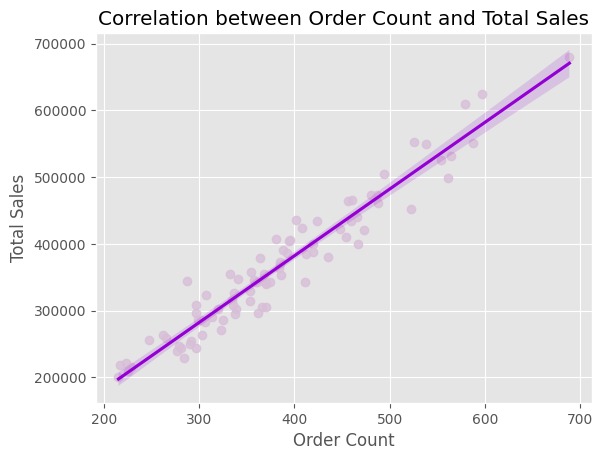

In [189]:
daily_stats = df.groupby('order_date').agg(total_sales = ('price', 'sum'), order_cnt = ('price', 'count')).reset_index()

sns.regplot(data = daily_stats, x = 'order_cnt', y = 'total_sales', scatter_kws = {'color': 'thistle'}, line_kws = {'color': 'darkviolet'})
plt.xlabel('Order Count')
plt.ylabel('Total Sales')
plt.title('Correlation between Order Count and Total Sales')
plt.show()

In [190]:
pearson_corr, p_value = stats.pearsonr(daily_stats['order_cnt'], daily_stats['total_sales'])

print(f'Pearson Correlation: {pearson_corr:.4f}')
print(f'P-value: {p_value:.4f}')

Pearson Correlation: 0.9642
P-value: 0.0000


### Insights
The plot shows an extremely strong positive linear correlation between order count and total sales. What this implies is that average order value is very stable day-to-day. If individual order values varied wildly, the points would be much more scattered around the line. The tight fit means you can fairly reliably predict a day's revenue just from knowing how many orders came in, which is useful for forecasting.

The Pearson correlation coefficient of 0.9642 indicates a very strong positive linear relationship between daily order count and total sales. The p-value of < 0.0001 confirms this correlation is statistically significant, meaning it is extremely unlikely to have occurred by chance. This supports the earlier observation from the regression plot that average order value remains stable day-to-day and revenue is largely predictable from order volume alone.

## Correlation between sales in different regions

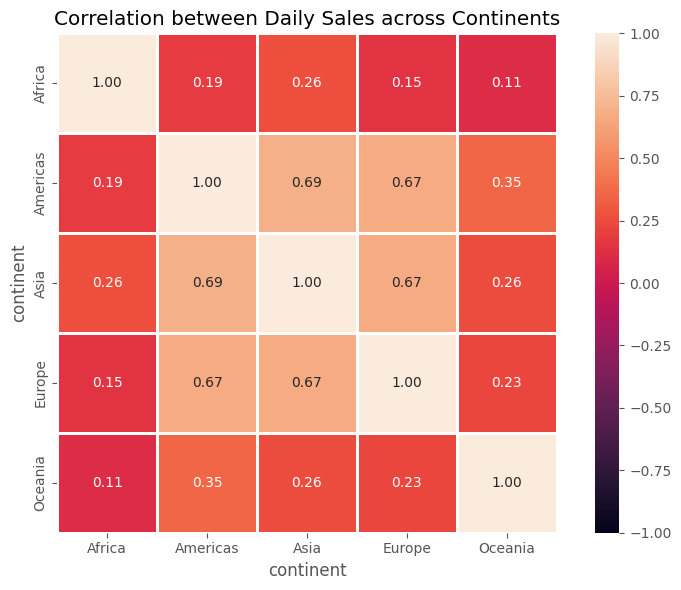


Statistical Significance Tests:
--------------------------------------------------
Africa          vs Americas       : r= 0.186, p=0.0834 ns
Africa          vs Asia           : r= 0.263, p=0.0134 *
Africa          vs Europe         : r= 0.147, p=0.1703 ns
Africa          vs Oceania        : r= 0.114, p=0.2885 ns
Americas        vs Asia           : r= 0.692, p=0.0000 ***
Americas        vs Europe         : r= 0.670, p=0.0000 ***
Americas        vs Oceania        : r= 0.354, p=0.0007 ***
Asia            vs Europe         : r= 0.668, p=0.0000 ***
Asia            vs Oceania        : r= 0.256, p=0.0160 *
Europe          vs Oceania        : r= 0.228, p=0.0329 *

* p<0.05, ** p<0.01, *** p<0.001, ns=not significant


In [191]:
continent_sales = df[df['continent'] != '(not set)'].groupby(['order_date', 'continent'], observed=True)['price'].sum().unstack(fill_value=0)
correlation_matrix = continent_sales.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='rocket', center=0,
            vmin=-1, vmax=1, square=True, linewidths=1, fmt='.2f')
plt.title('Correlation between Daily Sales across Continents')
plt.tight_layout()
plt.show()

continents = continent_sales.columns
n = len(continents)

print('\nStatistical Significance Tests:')
print('-'*50)

for i in range(n):
    for j in range(i+1, n):
        cont1, cont2 = continents[i], continents[j]
        corr_coef, p_value = stats.pearsonr(continent_sales[cont1], continent_sales[cont2])

        significance = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'

        print(f'{cont1:15} vs {cont2:15}: r={corr_coef:6.3f}, p={p_value:.4f} {significance}')

print('\n* p<0.05, ** p<0.01, *** p<0.001, ns=not significant')

### Insights
The correlation matrix reveals several key patterns in cross-continental sales dynamics:

- **Americas as the global driver**: Sales in the Americas show moderate to strong positive correlations with Asia (r=0.69, p < 0.001), Europe (r=0.67, p < 0.001), and Oceania (r=0.35, p < 0.001), suggesting that when American sales rise, other major markets tend to follow. This likely reflects shared seasonal patterns (e.g., holiday shopping) or global economic trends.

- **Asia-Europe synchronization**: Asia and Europe also exhibit a strong positive correlation (r=0.67, p < 0.001), indicating these markets move together independently of Americas influence.

- **Africa operates independently**: Africa shows weak or statistically insignificant correlations with all other continents except Asia (r=0.26, p < 0.05). This suggests African market dynamics are largely disconnected from global trends, possibly due to different seasonal patterns, economic cycles, or data sparsity (Africa represents only ≈1% of total sales).

- **Oceania follows major markets**: Oceania correlates weakly but significantly with Americas (r=0.35, p < 0.001) and Asia (r=0.26, p < 0.05), though its small market size (≈1% of sales) limits interpretability.

## Correlation between sales by traffic channels

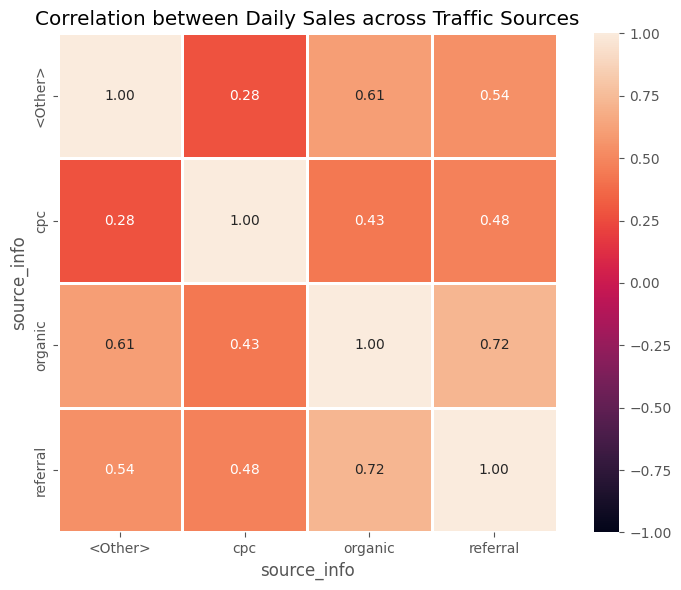


Statistical Significance Tests:
--------------------------------------------------
<Other>         vs cpc            : r= 0.277, p=0.0089 **
<Other>         vs organic        : r= 0.609, p=0.0000 ***
<Other>         vs referral       : r= 0.542, p=0.0000 ***
cpc             vs organic        : r= 0.430, p=0.0000 ***
cpc             vs referral       : r= 0.475, p=0.0000 ***
organic         vs referral       : r= 0.724, p=0.0000 ***

* p<0.05, ** p<0.01, *** p<0.001, ns=not significant


In [192]:
continent_sales = df_cleaned.groupby(['order_date', 'source_info'], observed=True)['price'].sum().unstack(fill_value=0)
correlation_matrix = continent_sales.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='rocket', center=0,
            vmin=-1, vmax=1, square=True, linewidths=1, fmt='.2f')
plt.title('Correlation between Daily Sales across Traffic Sources')
plt.tight_layout()
plt.show()

continents = continent_sales.columns
n = len(continents)

print('\nStatistical Significance Tests:')
print('-'*50)

for i in range(n):
    for j in range(i+1, n):
        cont1, cont2 = continents[i], continents[j]
        corr_coef, p_value = stats.pearsonr(continent_sales[cont1], continent_sales[cont2])

        significance = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'

        print(f'{cont1:15} vs {cont2:15}: r={corr_coef:6.3f}, p={p_value:.4f} {significance}')

print('\n* p<0.05, ** p<0.01, *** p<0.001, ns=not significant')

### Insights

All major traffic sources (organic, referral, CPC) show moderate to strong positive correlations with each other, with organic and referral being particularly synchronized (r=0.72, p < 0.001). This suggests traffic channels do not operate independently and high-traffic days see simultaneous increases across all channels, likely driven by shared external factors such as seasonal shopping patterns, promotional campaigns, or general market demand.

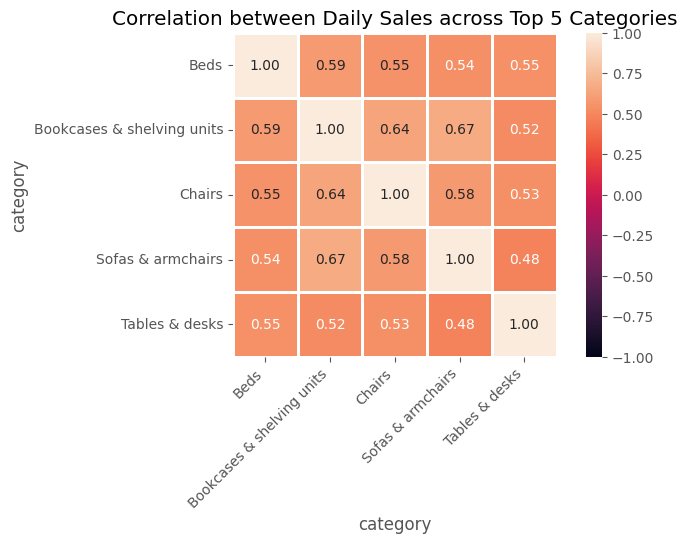


Statistical Significance Tests:
--------------------------------------------------
Beds            vs Bookcases & shelving units: r= 0.593, p=0.0000 ***
Beds            vs Chairs         : r= 0.554, p=0.0000 ***
Beds            vs Sofas & armchairs: r= 0.535, p=0.0000 ***
Beds            vs Tables & desks : r= 0.546, p=0.0000 ***
Bookcases & shelving units vs Chairs         : r= 0.637, p=0.0000 ***
Bookcases & shelving units vs Sofas & armchairs: r= 0.666, p=0.0000 ***
Bookcases & shelving units vs Tables & desks : r= 0.517, p=0.0000 ***
Chairs          vs Sofas & armchairs: r= 0.578, p=0.0000 ***
Chairs          vs Tables & desks : r= 0.531, p=0.0000 ***
Sofas & armchairs vs Tables & desks : r= 0.482, p=0.0000 ***

* p<0.05, ** p<0.01, *** p<0.001, ns=not significant


In [193]:
top_5_categories = df['category'].value_counts().head(5).index
continent_sales = df[df['category'].isin(top_5_categories)].groupby(['order_date', 'category'], observed=True)['price'].sum().unstack(fill_value=0)
correlation_matrix = continent_sales.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='rocket', center=0,
            vmin=-1, vmax=1, square=True, linewidths=1, fmt='.2f')
plt.title('Correlation between Daily Sales across Top 5 Categories')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

continents = continent_sales.columns
n = len(continents)

print('\nStatistical Significance Tests:')
print('-'*50)

for i in range(n):
    for j in range(i+1, n):
        cont1, cont2 = continents[i], continents[j]
        corr_coef, p_value = stats.pearsonr(continent_sales[cont1], continent_sales[cont2])

        significance = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'

        print(f'{cont1:15} vs {cont2:15}: r={corr_coef:6.3f}, p={p_value:.4f} {significance}')

print('\n* p<0.05, ** p<0.01, *** p<0.001, ns=not significant')

### Insights
The correlation matrix for the top 5 product categories reveals moderate positive correlations across all category pairs (r=0.48-0.67, all p < 0.001), indicating that sales across different furniture categories tend to rise and fall together rather than independently.

**Key findings:**
- **Bookcases & Sofas** show the strongest correlation (r=0.67), suggesting customers who browse for larger furniture items are also likely purchasing storage solutions, or that promotional periods drive sales across both categories simultaneously.
- **Chairs** correlate strongly with both Bookcases (r=0.64) and Sofas (r=0.58), reinforcing the pattern that seating and storage purchases often coincide.
- **Tables & desks** show the weakest correlations with other categories (r=0.48-0.55), suggesting slightly more independent purchasing behavior, possibly because desks are more task-specific purchases rather than general home furnishing.

The overall moderate correlation pattern suggests that daily sales are driven by common factors (promotions, seasonality, traffic volume) rather than customers making isolated category-specific purchases. This supports the earlier finding that high-traffic days lift sales across all product lines.

## Sales by registration status analytics

In [194]:
registered_orders = df[df['user_id'].notna()]['price'].dropna()
unregistered_orders = df[df['user_id'].isna()]['price'].dropna()

shapiro_reg = stats.shapiro(registered_orders)
shapiro_unreg = stats.shapiro(unregistered_orders)

print(f'Shapiro-Wilk (Registered): statistic={shapiro_reg.statistic:.4f}, p-value={shapiro_reg.pvalue:.10f}')
print(f'Shapiro-Wilk (Unregistered): statistic={shapiro_unreg.statistic:.4f}, p-value={shapiro_unreg.pvalue:.10f}')

stat, p = mannwhitneyu(registered_orders, unregistered_orders, alternative='two-sided')
print(f'\nMann–Whitney U test: statistic={stat:.2f}, p-value={p:.10f}')

print(f'\nRegistered orders: mean={registered_orders.mean():.2f}, median={registered_orders.median():.2f}, n={len(registered_orders)}')
print(f'Unregistered orders: mean={unregistered_orders.mean():.2f}, median={unregistered_orders.median():.2f}, n={len(unregistered_orders)}')

Shapiro-Wilk (Registered): statistic=0.6657, p-value=0.0000000000
Shapiro-Wilk (Unregistered): statistic=0.6811, p-value=0.0000000000

Mann–Whitney U test: statistic=41771375.00, p-value=0.0415908966

Registered orders: mean=928.63, median=399.00, n=2781
Unregistered orders: mean=955.53, median=445.00, n=30757


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 30757.
  res = hypotest_fun_out(*samples, **kwds)


### Insights

The Shapiro-Wilk test confirms both groups are non-normally distributed (p < 0.05), justifying the use of non-parametric testing. The Mann-Whitney U test reveals a statistically significant difference (p=0.042) between registered and unregistered order values, with unregistered users having a slightly higher mean (955.53 USD vs 928.63 USD).

However, the medians are nearly identical (445 USD vs 399 USD), suggesting the difference is driven by a small number of high-value outlier orders from unregistered users rather than systematic behavioral differences. From a practical business perspective, this ≈27 USD mean difference is likely not meaningful.

## Sessions by traffic source analytics (Organic, CPC & Referral)

In [195]:
organic = df[df['source_info'] == 'organic'].groupby('order_date')['price'].sum()
cpc = df[df['source_info'] == 'cpc'].groupby('order_date')['price'].sum()
referral = df[df['source_info'] == 'referral'].groupby('order_date')['price'].sum()

stat, p_val_channels = kruskal(organic, cpc, referral)

print(f'Kruskal-Wallis statistic: {stat}')
print(f'P-value: {p_val_channels:.10f}')

if p_val_channels < 0.05:
    print('Difference between traffic channels is statistically significant')
else:
    print('Difference between traffic channels is not statistically significant')

Kruskal-Wallis statistic: 218.8244464369251
P-value: 0.0000000000
Difference between traffic channels is statistically significant


### Insights

The Kruskal-Wallis test reveals a statistically significant difference in daily sales distributions across the three main traffic sources (organic, CPC, and referral) with p < 0.001. This confirms that organic, CPC, and referral channels generate meaningfully different sales patterns on a day-to-day basis, despite their moderate correlations observed earlier. Organic consistently drives the highest absolute sales volume (≈34% of total revenue), while CPC remains the weakest performer (≈4% of revenue). The significant p-value indicates these differences are not due to random variation but reflect genuine disparities in channel performance.

In [196]:
europe_total = len(df[df['continent'] == 'Europe'])
europe_organic = len(df[(df['continent'] == 'Europe') & (df['source_info'] == 'organic')])

americas_total = len(df[df['continent'] == 'Americas'])
americas_organic = len(df[(df['continent'] == 'Americas') & (df['source_info'] == 'organic')])

europe_prop = europe_organic / europe_total
americas_prop = americas_organic / americas_total

print(f'Europe: {europe_organic}/{europe_total} sessions organic ({europe_prop:.2%})')
print(f'Americas: {americas_organic}/{americas_total} sessions organic ({americas_prop:.2%})')
print()

counts = [europe_organic, americas_organic]
nobs = [europe_total, americas_total]

z_stat, p_value = proportions_ztest(counts, nobs)

print(f'Two-proportion z-test:')
print(f'Z-statistic: {z_stat:.4f}')
print(f'P-value: {p_value:.4f}')

if p_value < 0.05:
    print('\nThe difference in organic traffic proportions is statistically significant (p < 0.05)')
else:
    print('\nThe difference in organic traffic proportions is not statistically significant (p > 0.05)')

Europe: 22190/65135 sessions organic (34.07%)
Americas: 65783/193179 sessions organic (34.05%)

Two-proportion z-test:
Z-statistic: 0.0691
P-value: 0.9449

The difference in organic traffic proportions is not statistically significant (p > 0.05)


### Insights

Europe and Americas have approximately the same % of organic traffic (≈34%). A two-proportion z-test shows this difference is not statistically significant (z= 0.069, p=0.9449), suggesting organic traffic proportions are comparable across regions.

# Conclusions

This analysis of 349,545 ecommerce sessions from November 2020 to January 2021 reveals several key insights into business performance and customer behavior:

- **Geographic & Market Dynamics:**
The Americas dominate revenue (17.7M USD, 55%) and order volume (18,553 orders), with the United States alone accounting for ≈44% of global sales. Asia and Europe represent secondary markets at 24% and 19% of revenue respectively. Cross-continental correlation analysis shows that Americas, Asia, and Europe exhibit moderate positive correlations (r=0.67-0.69), suggesting synchronized purchasing patterns driven by shared seasonal trends like holiday shopping. Africa and Oceania operate largely independently with minimal market share.

- **Product Performance:**
Sofas & armchairs lead in revenue (26.24%, 8.4M USD) but rank third in order volume, indicating high-value, low-frequency purchases. Conversely, Bookcases & shelving units dominate order count (22.75%) but contribute less revenue (11.39%), reflecting affordable, frequent purchases. This revenue-vs-volume discrepancy highlights two distinct customer behaviors: occasional big-ticket purchases versus regular smaller transactions. Category sales show moderate correlations (r=0.48-0.67), suggesting promotional periods and traffic spikes lift all categories simultaneously.

- **Traffic & Acquisition:**
Organic search drives 34% of revenue, establishing it as the primary acquisition channel, followed by direct traffic (23%) and referral (18%). Paid CPC accounts for only 4% of revenue, indicating heavy reliance on non-paid channels. All traffic sources exhibit moderate to strong correlations with each other (r=0.43-0.72), confirming that high-traffic days generate increases across all channels simultaneously rather than isolated spikes in individual sources.

- **Device & User Behavior:**
Desktop dominates with 59% of sales, while mobile represents 39% and tablet is negligible at 2%. Average order values remain consistent across devices (≈950 USD mean, ≈440 USD median), indicating no device-specific spending patterns. The mean-median gap reveals significant outlier orders pulling averages upward across all segments.

- **Registration & Conversion:**
Only 7.99% of sessions come from registered users, with ≈20% of orders placed by guest users consistently across all continents. Subscription status shows no meaningful impact on average order value (921 USD vs 965 USD), suggesting email engagement does not correlate with purchase value. This represents a significant growth opportunity for improving user registration and email capture strategies.

- **Temporal Patterns:**
Sales peaked dramatically in early December (≈680K daily) corresponding to Black Friday/Cyber Monday, with this spike primarily driven by Americas and organic traffic. Daily order count exhibits an exceptionally strong correlation with total sales (r=0.96, p < 0.001), indicating stable average order values and predictable revenue patterns based on order volume alone.

- **Data Quality Considerations:**
The mobile_model_name field mixes browsers and device models, limiting device-level analysis. Approximately 6.4% of revenue has deleted attribution data, likely reflecting GDPR compliance. The 'unknown' and '(not set)' categories across various dimensions suggest data collection inconsistencies worth addressing in future implementations.